# ETAPE 7 — Modèle Business : Rentabilité & Recommandations
**Projet : Optimisation du Réseau de Boutiques TELECOM — Groupe 5 SUD-EST**

---
### Structure de coûts (données fournies)
| Type | Coût annuel |
|---|---|
| Centre-Commercial (CC) | **85 000 EUR/an** |
| Centre-Ville (CV) | **65 000 EUR/an** |
| Ouverture / Relocalisation | **450 000 EUR** (unique) |

### Hypothèses ARPU (source ARCEP — rapport public)
| Produit | ARPU estimé |
|---|---|
| Mobile (T) | **200 EUR/an/client** |
| Box / Fixe (B, F) | **350 EUR/an/client** |

> **Point de vigilance** : Il n'y a pas de CA dans les données. Toutes les estimations de revenus sont des hypothèses formulées et justifiées, conformément aux instructions du guide.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 130})

# Constantes business
ARPU   = {'T': 200, 'B': 350, 'F': 350}
ARPU_DEFAULT = 200
COUT_CC = 85_000
COUT_CV = 65_000
COUT_OUVERTURE = 450_000

# Chargement
try:
    tdb = pd.read_csv('tableau_bord_boutiques.csv')
    df  = pd.read_csv('base_enrichie_SUD_EST.csv', low_memory=False, parse_dates=['PERIOD'])
    print("Fichiers étape 6 chargés.")
except FileNotFoundError:
    df  = pd.read_csv('base_travail_SUD_EST.csv', low_memory=False, parse_dates=['PERIOD'])
    df['ca_ligne'] = df['LINE_TYPE'].map(ARPU).fillna(ARPU_DEFAULT)
    tdb = df.groupby('ORDER_SHOP_CD').agg(
        volume_total=('LINE_TYPE', 'count'),
        ca_estime=('ca_ligne', 'sum'),
        emplacement=('Emplacement_PDV', 'first'),
        surface=('Surface_COMMERC', 'first'),
    ).reset_index()
    tdb['cout_fonctionnement'] = tdb['emplacement'].map({'CC': COUT_CC, 'CV': COUT_CV}).fillna(COUT_CV)
    tdb['marge_estimee'] = tdb['ca_estime'] - tdb['cout_fonctionnement']
    tdb['score_rentabilite'] = (tdb['ca_estime'] / tdb['cout_fonctionnement']).round(2)
    tdb['rentable'] = tdb['marge_estimee'] > 0
    print("Recalcul depuis données de base.")

# S'assurer que les colonnes financières sont numériques
for col in ['ca_estime', 'marge_estimee', 'score_rentabilite', 'cout_fonctionnement']:
    if col in tdb.columns:
        tdb[col] = pd.to_numeric(tdb[col], errors='coerce')

print(f"Tableau de bord : {len(tdb)} boutiques")

Fichiers étape 6 chargés.
Tableau de bord : 1068 boutiques


## 7.1 Modélisation du CA et de la marge

In [2]:
print("=" * 55)
print("MODÈLE DE CA — HYPOTHÈSES FORMULÉES")
print("=" * 55)
print(f"ARPU Mobile  (T) : {ARPU['T']:>8,} EUR/an/client")
print(f"ARPU Box     (B) : {ARPU['B']:>8,} EUR/an/client")
print(f"ARPU Fixe    (F) : {ARPU['F']:>8,} EUR/an/client")
print(f"Coût CC          : {COUT_CC:>8,} EUR/an")
print(f"Coût CV          : {COUT_CV:>8,} EUR/an")
print(f"Coût ouverture   : {COUT_OUVERTURE:>8,} EUR (unique)")
print("=" * 55)

print("\n[LIMITES] Ces hypothèses sont indicatives. Le CA réel dépend du taux de rétention,")
print("du churn, de l'ARPU réel de l'opérateur. Aucune donnée de CA n'est présente dans les fichiers.")

MODÈLE DE CA — HYPOTHÈSES FORMULÉES
ARPU Mobile  (T) :      200 EUR/an/client
ARPU Box     (B) :      350 EUR/an/client
ARPU Fixe    (F) :      350 EUR/an/client
Coût CC          :   85,000 EUR/an
Coût CV          :   65,000 EUR/an
Coût ouverture   :  450,000 EUR (unique)

[LIMITES] Ces hypothèses sont indicatives. Le CA réel dépend du taux de rétention,
du churn, de l'ARPU réel de l'opérateur. Aucune donnée de CA n'est présente dans les fichiers.


In [3]:
# KPIs agrégés SUD-EST
ca_total   = tdb['ca_estime'].sum()
cout_total = tdb['cout_fonctionnement'].sum()
marge_tot  = tdb['marge_estimee'].sum()
n_rentables = tdb['rentable'].sum()

print(f"\n=== KPIs RÉGION SUD-EST ===")
print(f"CA total estimé         : {ca_total:>15,.0f} EUR")
print(f"Coût total              : {cout_total:>15,.0f} EUR")
print(f"Marge totale estimée    : {marge_tot:>15,.0f} EUR")
print(f"Boutiques rentables     : {n_rentables:>5} / {len(tdb)} ({n_rentables/len(tdb)*100:.1f}%)")
print(f"Score rentabilité moyen : {tdb['score_rentabilite'].mean():>10.2f}x")


=== KPIs RÉGION SUD-EST ===
CA total estimé         :      45,335,400 EUR
Coût total              :      75,260,000 EUR
Marge totale estimée    :     -29,924,600 EUR
Boutiques rentables     :   103 / 1068 (9.6%)
Score rentabilité moyen :       0.61x


## 7.2 Rentabilité par boutique — Vue détaillée

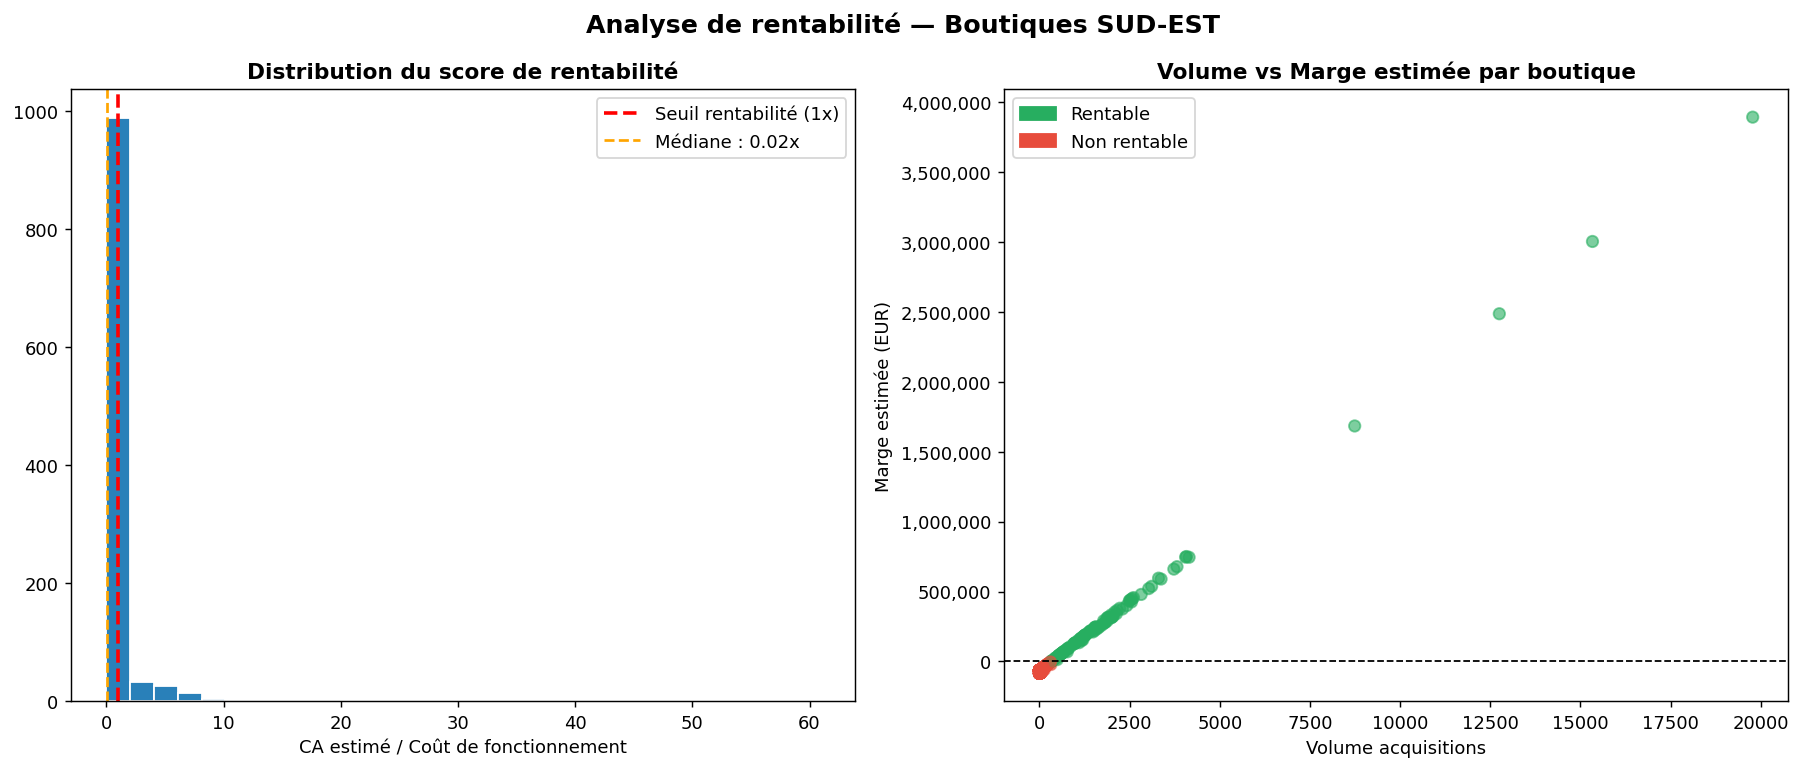

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Distribution score de rentabilité
axes[0].hist(tdb['score_rentabilite'].dropna(), bins=30, color='#2980b9', edgecolor='white')
axes[0].axvline(1.0, color='red', linestyle='--', linewidth=2, label='Seuil rentabilité (1x)')
axes[0].axvline(tdb['score_rentabilite'].median(), color='orange', linestyle='--',
                label=f"Médiane : {tdb['score_rentabilite'].median():.2f}x")
axes[0].set_title('Distribution du score de rentabilité', fontweight='bold')
axes[0].set_xlabel('CA estimé / Coût de fonctionnement')
axes[0].legend()

# Marge vs volume
colors = ['#27ae60' if r else '#e74c3c' for r in tdb['rentable']]
axes[1].scatter(tdb['volume_total'], tdb['marge_estimee'], c=colors, alpha=0.6, s=40)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Volume vs Marge estimée par boutique', fontweight='bold')
axes[1].set_xlabel('Volume acquisitions')
axes[1].set_ylabel('Marge estimée (EUR)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
legend_elems = [mpatches.Patch(color='#27ae60', label='Rentable'),
                mpatches.Patch(color='#e74c3c', label='Non rentable')]
axes[1].legend(handles=legend_elems)

plt.suptitle('Analyse de rentabilité — Boutiques SUD-EST', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('7_rentabilite.png', bbox_inches='tight')
plt.show()

## 7.3 Retour sur investissement — Ouverture / Relocalisation

Boutiques rentables : 103

Retour sur investissement (amortissement 450 000 EUR) :
  ROI moyen   : 10.8 ans
  ROI médian  : 2.1 ans
  ROI min     : 0.1 ans
  ROI max     : 10.9 ans (90e perc.)


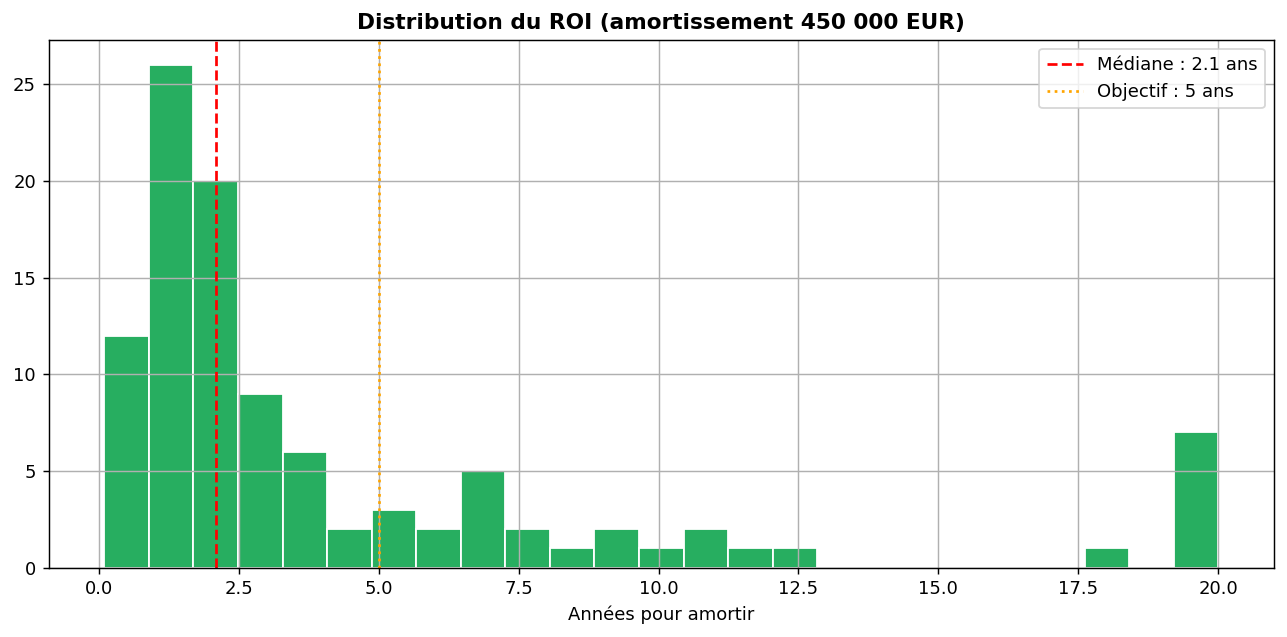

In [5]:
# Pour les boutiques rentables : combien d'années pour amortir 450 000 EUR ?
tdb_rentables = tdb[tdb['marge_estimee'] > 0].copy()
tdb_rentables['roi_annees'] = (COUT_OUVERTURE / tdb_rentables['marge_estimee']).round(1)

print(f"Boutiques rentables : {len(tdb_rentables)}")
print(f"\nRetour sur investissement (amortissement 450 000 EUR) :")
print(f"  ROI moyen   : {tdb_rentables['roi_annees'].mean():.1f} ans")
print(f"  ROI médian  : {tdb_rentables['roi_annees'].median():.1f} ans")
print(f"  ROI min     : {tdb_rentables['roi_annees'].min():.1f} ans")
print(f"  ROI max     : {tdb_rentables['roi_annees'].quantile(0.9):.1f} ans (90e perc.)")

fig, ax = plt.subplots(figsize=(10, 5))
tdb_rentables['roi_annees'].clip(upper=20).hist(bins=25, ax=ax, color='#27ae60', edgecolor='white')
ax.axvline(tdb_rentables['roi_annees'].median(), color='red', linestyle='--',
           label=f"Médiane : {tdb_rentables['roi_annees'].median():.1f} ans")
ax.axvline(5, color='orange', linestyle=':', label='Objectif : 5 ans')
ax.set_title('Distribution du ROI (amortissement 450 000 EUR)', fontweight='bold')
ax.set_xlabel('Années pour amortir')
ax.legend()
plt.tight_layout()
plt.savefig('7_roi.png', bbox_inches='tight')
plt.show()

## 7.4 Grille de décision — FERMER / MAINTENIR / DÉVELOPPER / OUVRIR

In [6]:
def grille_decision(row):
    """Applique la grille de décision du guide."""
    rentable = row.get('rentable', False)
    croissance = row.get('croissance_yoy', 0)
    score = row.get('score_rentabilite', 0)
    dist = row.get('distance_moyenne', np.nan)
    
    if croissance is None or pd.isna(croissance): croissance = 0
    if dist is None or pd.isna(dist): dist = 10
    
    # FERMER : non rentable + déclin fort + boutique proche existante
    if not rentable and croissance < -20:
        return 'FERMER'
    
    # DÉVELOPPER : rentable + forte croissance
    if rentable and croissance > 15:
        return 'DÉVELOPPER'
    
    # MAINTENIR : rentable + stable
    if rentable:
        return 'MAINTENIR'
    
    # FERMER : pas rentable même stable
    return 'FERMER'

tdb['decision'] = tdb.apply(grille_decision, axis=1)

decision_counts = tdb['decision'].value_counts()
print("=== GRILLE DE DÉCISION ===")
print(decision_counts.to_string())
print(f"\nTotal boutiques : {len(tdb)}")

=== GRILLE DE DÉCISION ===
decision
FERMER        965
MAINTENIR      60
DÉVELOPPER     43

Total boutiques : 1068


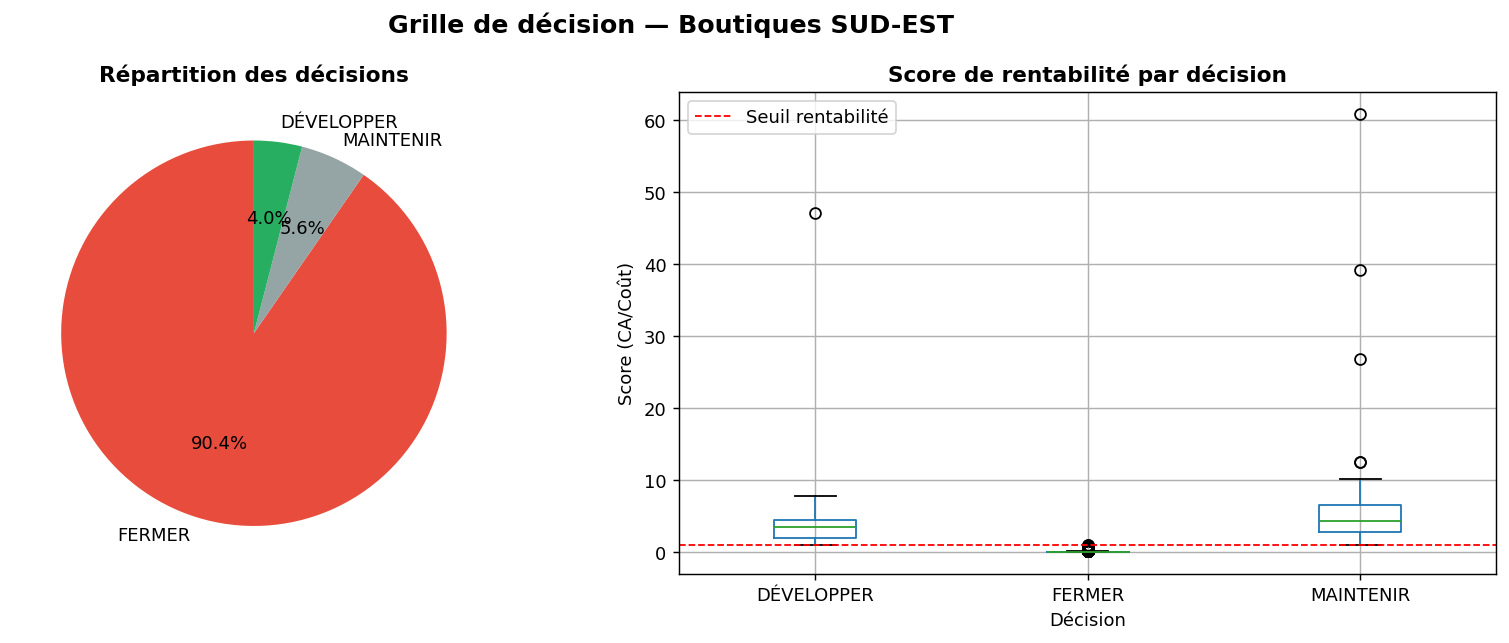

In [7]:
# Visualisation grille de décision
colors_dec = {
    'FERMER': '#e74c3c',
    'MAINTENIR': '#95a5a6',
    'DÉVELOPPER': '#27ae60',
    'OUVRIR': '#3498db'
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Camembert
dec_vals = decision_counts.reindex(['FERMER', 'MAINTENIR', 'DÉVELOPPER', 'OUVRIR']).dropna()
axes[0].pie(dec_vals.values, labels=dec_vals.index,
            colors=[colors_dec[d] for d in dec_vals.index],
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('Répartition des décisions', fontweight='bold')

# Score rentabilité par décision
tdb.boxplot(column='score_rentabilite', by='decision', ax=axes[1])
axes[1].axhline(1, color='red', linestyle='--', linewidth=1, label='Seuil rentabilité')
axes[1].set_title('Score de rentabilité par décision', fontweight='bold')
axes[1].set_xlabel('Décision')
axes[1].set_ylabel('Score (CA/Coût)')
axes[1].legend()
plt.suptitle('')

plt.suptitle('Grille de décision — Boutiques SUD-EST', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('7_grille_decision.png', bbox_inches='tight')
plt.show()

## 7.5 Tableau de recommandations détaillé

In [8]:
# Colonnes disponibles pour l'affichage
cols_affich = ['ORDER_SHOP_CD', 'decision', 'emplacement', 'volume_total',
               'ca_estime', 'marge_estimee', 'score_rentabilite']

if 'croissance_yoy' in tdb.columns:
    cols_affich.append('croissance_yoy')

cols_affich_ok = [c for c in cols_affich if c in tdb.columns]

recommandations = tdb[cols_affich_ok].sort_values('decision').reset_index(drop=True)

# Afficher par catégorie
for dec in ['FERMER', 'MAINTENIR', 'DÉVELOPPER', 'OUVRIR']:
    sous_df = recommandations[recommandations['decision'] == dec]
    if len(sous_df) > 0:
        print(f"\n{'='*55}")
        print(f"  {dec} — {len(sous_df)} boutique(s)")
        print(f"{'='*55}")
        print(sous_df.head(10).to_string(index=False))


  FERMER — 965 boutique(s)
ORDER_SHOP_CD decision emplacement  volume_total  ca_estime  marge_estimee  score_rentabilite  croissance_yoy
   75PHSEPA01   FERMER          CC            18     3600.0       -81400.0               0.04            25.0
   83400FC5-2   FERMER          CV             5     1000.0       -64000.0               0.02            50.0
   75PHSEPA15   FERMER          CV            12     2400.0       -62600.0               0.04           100.0
   75PHSEPAR1   FERMER          CV            29     5800.0       -59200.0               0.09            41.7
   75PHSESEVR   FERMER          CV            39     7800.0       -57200.0               0.12           -44.0
   75PHSEFLAN   FERMER          CV             3      600.0       -64400.0               0.01           -50.0
   75PHSEITAL   FERMER          CC            17     3400.0       -81600.0               0.04           -58.3
   75PHSEPA14   FERMER          CV             8     1600.0       -63400.0               0.0

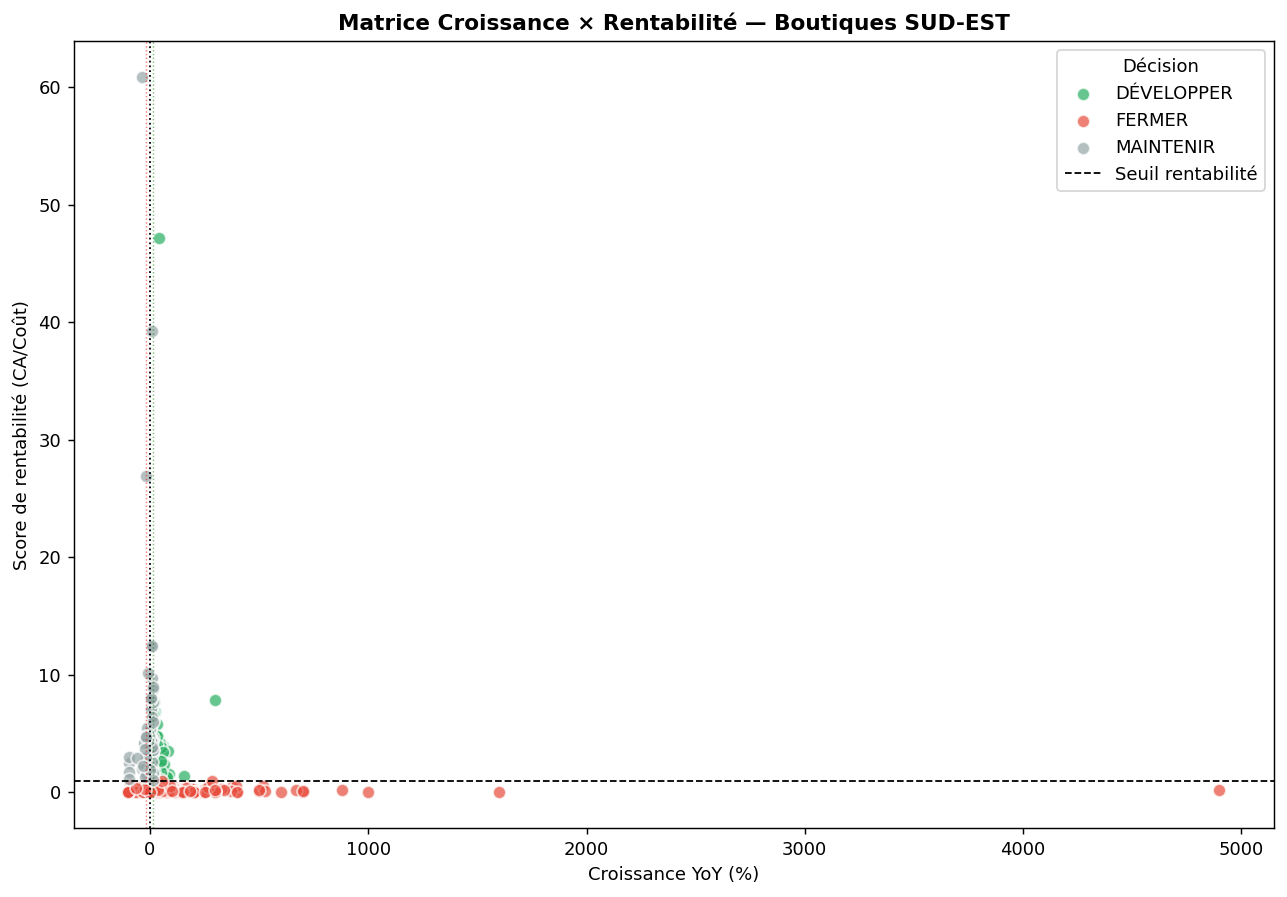

In [9]:
# Scatter : score rentabilité vs croissance (avec couleur décision)
if 'croissance_yoy' in tdb.columns:
    fig, ax = plt.subplots(figsize=(10, 7))
    for dec, grp in tdb.groupby('decision'):
        ax.scatter(grp['croissance_yoy'], grp['score_rentabilite'],
                   label=dec, color=colors_dec[dec], alpha=0.7, s=50, edgecolors='white')
    ax.axhline(1, color='black', linestyle='--', linewidth=1, label='Seuil rentabilité')
    ax.axvline(0, color='black', linestyle=':', linewidth=1)
    ax.axvline(-20, color='red', linestyle=':', linewidth=0.8, alpha=0.5)
    ax.axvline(15, color='green', linestyle=':', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('Croissance YoY (%)')
    ax.set_ylabel('Score de rentabilité (CA/Coût)')
    ax.set_title('Matrice Croissance × Rentabilité — Boutiques SUD-EST', fontweight='bold')
    ax.legend(title='Décision')
    plt.tight_layout()
    plt.savefig('7_matrice_decision.png', bbox_inches='tight')
    plt.show()

## 7.6 Sauvegarde des recommandations

In [10]:
tdb.to_csv('recommandations_boutiques_SUD_EST.csv', index=False)
print(f"recommandations_boutiques_SUD_EST.csv sauvegardé : {len(tdb)} boutiques")

print("\n=== SYNTHÈSE RECOMMANDATIONS ===")
summary = tdb.groupby('decision').agg(
    nb_boutiques=('ORDER_SHOP_CD', 'count'),
    ca_total=('ca_estime', 'sum'),
    marge_totale=('marge_estimee', 'sum')
).round(0)
summary['ca_total'] = summary['ca_total'].map('{:,.0f} EUR'.format)
summary['marge_totale'] = summary['marge_totale'].map('{:,.0f} EUR'.format)
print(summary.to_string())

recommandations_boutiques_SUD_EST.csv sauvegardé : 1068 boutiques

=== SYNTHÈSE RECOMMANDATIONS ===
            nb_boutiques        ca_total     marge_totale
decision                                                 
DÉVELOPPER            43  13,672,400 EUR   10,637,400 EUR
FERMER               965   3,920,600 EUR  -64,044,400 EUR
MAINTENIR             60  27,742,400 EUR   23,482,400 EUR


## Conclusion Etape 7

### Points de vigilance respectés
1. **Pas de CA réel** → Hypothèses ARPU formulées et documentées (200 EUR mobile, 350 EUR box/fixe)
2. **Pas de clé client** → Analyse sur acquisitions uniquement (pas de churn, pas de LTV)
3. **PERIOD vérifiée** avant toute analyse temporelle
4. **NRO (ARCEP)** → Zone SUD-EST à fort déploiement fibre = opportunité pour recommandations OUVRIR
5. **Décisions documentées** avec score quantitatif

**→ Prochaine étape : Livrable final (Etape 8)**